# Explainable Blended Weight Analysis (North/South)

??:
- ?? ??? ?? ???(`global + SHAP + local`)? ????,
- ???(??/???/?????/??/????) ??? ????? ???
- ? ?? ??? ???? ?? ????? ?? ??? ??? ???

?? ??:
1) `pure_blend`: ?? ??? ??
2) `balanced_explainable`: ?? ??? ? ??? ?? ???? ???(??)


In [1]:
from pathlib import Path
import re
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ Config ------------------
MODE = "balanced_explainable"   # "pure_blend" or "balanced_explainable"
ALPHA = 0.5                      # base blend: w = ALPHA*global + (1-ALPHA)*local
TOP_N_GLOBAL = 10
TOP_N_LOCAL = 10

# Explainable group targets (must sum to 1.0)
TARGET_GROUP_SHARES = {
    "Terrain": 0.40,
    "TrafficVolume": 0.35,
    "PedInfra": 0.12,
    "TrafficSpeed": 0.08,
    "Network": 0.05,
}
if abs(sum(TARGET_GROUP_SHARES.values()) - 1.0) > 1e-9:
    raise ValueError("TARGET_GROUP_SHARES ?? 1.0??? ???.")

ROOT = Path(r"C:\Users\a0109\.jupyter")
BASE = sorted(ROOT.glob("*/data/grf_06_outputs"))[0]
print("BASE:", BASE)

pat = re.compile(r"_(\d{8}_\d{6})\.csv$")

def latest_file(prefix: str) -> Path:
    files = list(BASE.glob(f"{prefix}_*.csv"))
    tagged = []
    for f in files:
        m = pat.search(f.name)
        if m:
            tagged.append((m.group(1), f))
    if not tagged:
        raise FileNotFoundError(f"{prefix}_*.csv ??? ????.")
    tagged.sort(key=lambda x: x[0], reverse=True)
    return tagged[0][1]

p_global = latest_file("global_importance")
p_shap = latest_file("shap_importance")
p_local = latest_file("local_importance")
p_xshap = latest_file("X_shap")

print("global:", p_global.name)
print("shap:", p_shap.name)
print("local:", p_local.name)
print("x_shap:", p_xshap.name)

global_df = pd.read_csv(p_global)
shap_df = pd.read_csv(p_shap)
local_df = pd.read_csv(p_local)
X_shap = pd.read_csv(p_xshap)


BASE: C:\Users\a0109\.jupyter\1최종_LH\data\grf_06_outputs
global: global_importance_20260228_115111.csv
shap: shap_importance_20260228_115111.csv
local: local_importance_20260228_115111.csv
x_shap: X_shap_20260228_115111.csv


In [2]:
# 1) Global evidence weight
joined = global_df[["feature", "importance_reg"]].merge(
    shap_df[["feature", "mean_abs_shap"]], on="feature", how="left"
).fillna({"mean_abs_shap": 0.0})

joined["norm_global"] = joined["importance_reg"] / joined["importance_reg"].sum()
joined["norm_shap"] = joined["mean_abs_shap"] / joined["mean_abs_shap"].sum()
joined["w_global_raw"] = 0.5 * joined["norm_global"] + 0.5 * joined["norm_shap"]
joined = joined.sort_values("w_global_raw", ascending=False).reset_index(drop=True)

global_top = joined.head(TOP_N_GLOBAL).copy()
global_top["w_global"] = global_top["w_global_raw"] / global_top["w_global_raw"].sum()

print(f"Global top{TOP_N_GLOBAL} coverage = {global_top['w_global_raw'].sum():.4f}")
display(global_top[["feature", "importance_reg", "mean_abs_shap", "w_global"]])


Global top10 coverage = 0.8425


,feature,importance_reg,mean_abs_shap,w_global
0,grid_100m_traffic_final_by_timebins_total_AADT...,0.386092,0.048315,0.421534
1,slope_mean,0.073416,0.016005,0.107308
2,grid_100m_traffic_final_by_timebins_total_AADT...,0.099554,0.009398,0.096504
3,grid_100m_traffic_final_by_timebins_total_AADT...,0.061192,0.009887,0.075688
4,hill_mean,0.062630,0.007241,0.066003
5,cctv_cnt,0.032907,0.010224,0.060246
6,crosswalk_cnt,0.024365,0.007766,0.045386
7,grid_100m_traffic_final_by_timebins_avg_speed_...,0.030243,0.006834,0.045164
8,grid_100m_traffic_final_by_timebins_avg_speed_...,0.029493,0.006557,0.043614
9,grid_100m_traffic_final_by_timebins_total_AADT...,0.034755,0.004502,0.038553


In [3]:
# 2) Local evidence weight (North/South)
if "north_mean" not in X_shap.columns:
    raise ValueError("X_shap? north_mean ??? ????.")
if len(local_df) != len(X_shap):
    raise ValueError(f"row mismatch: local={len(local_df)}, X_shap={len(X_shap)}")

df = local_df.copy()
df["north_mean"] = X_shap["north_mean"].values
thr = float(df["north_mean"].median())
df["region_ns"] = np.where(df["north_mean"] >= thr, "North", "South")

imp_cols = [c for c in df.columns if c.startswith("local_imp_")]


def local_top_weights(region: str, top_n: int = TOP_N_LOCAL) -> pd.DataFrame:
    d = df[df["region_ns"] == region]
    m = d[imp_cols].mean(axis=0).sort_values(ascending=False)
    top = m.head(top_n)
    out = pd.DataFrame({
        "feature": top.index.str.replace("local_imp_", "", regex=False),
        "local_mean_imp": top.values,
    })
    out["w_local"] = out["local_mean_imp"] / out["local_mean_imp"].sum()
    return out

north_local = local_top_weights("North")
south_local = local_top_weights("South")

print(f"north_mean median threshold = {thr:.12f}")
print("North samples:", (df["region_ns"] == "North").sum(), "| South samples:", (df["region_ns"] == "South").sum())

display(north_local)
display(south_local)


north_mean median threshold = 0.000000000001
North samples: 4817 | South samples: 4817


,feature,local_mean_imp,w_local
0,slope_mean,0.115265,0.240099
1,hill_mean,0.098565,0.205311
2,grid_100m_traffic_final_by_timebins_total_AADT...,0.042467,0.088459
3,grid_100m_traffic_final_by_timebins_total_AADT...,0.042457,0.088439
4,grid_100m_traffic_final_by_timebins_total_AADT...,0.041657,0.086771
5,grid_100m_traffic_final_by_timebins_total_AADT...,0.036717,0.076482
6,grid_100m_traffic_final_by_timebins_total_AADT...,0.028513,0.059394
7,cctv_cnt,0.025239,0.052572
8,grid_100m_traffic_final_by_timebins_frin_cg,0.025181,0.052452
9,grid_100m_traffic_final_by_timebins_avg_speed_...,0.024013,0.050020


,feature,local_mean_imp,w_local
0,slope_mean,0.110997,0.244725
1,hill_mean,0.081851,0.180464
2,grid_100m_traffic_final_by_timebins_total_AADT...,0.044281,0.097630
3,cctv_cnt,0.039009,0.086007
4,grid_100m_traffic_final_by_timebins_total_AADT...,0.036594,0.080682
5,grid_100m_traffic_final_by_timebins_total_AADT...,0.035475,0.078214
6,grid_100m_traffic_final_by_timebins_total_AADT...,0.031046,0.068450
7,grid_100m_traffic_final_by_timebins_total_AADT...,0.027174,0.059912
8,grid_100m_traffic_final_by_timebins_link_cnt,0.024868,0.054829
9,grid_100m_traffic_final_by_timebins_avg_speed_...,0.022264,0.049086


In [4]:
# 3) Blend and (optional) rebalance by explainable group targets

def feature_group(feature: str) -> str:
    if feature in {"slope_mean", "hill_mean"}:
        return "Terrain"
    if "total_AADT" in feature:
        return "TrafficVolume"
    if "avg_speed" in feature:
        return "TrafficSpeed"
    if any(x in feature for x in ["crosswalk", "cctv", "busstop", "school", "kindergarten", "daycare", "speedbump"]):
        return "PedInfra"
    if any(x in feature for x in ["link_cnt", "frin_cg", "ti_cg"]):
        return "Network"
    return "Other"


def pure_blend(local_w_df: pd.DataFrame, region_name: str, alpha: float = ALPHA) -> pd.DataFrame:
    g = global_top[["feature", "w_global"]].copy()
    l = local_w_df[["feature", "w_local"]].copy()

    feats = sorted(set(g["feature"]).union(set(l["feature"])))
    out = pd.DataFrame({"feature": feats})
    out = out.merge(g, on="feature", how="left").merge(l, on="feature", how="left")
    out[["w_global", "w_local"]] = out[["w_global", "w_local"]].fillna(0.0)

    out["global_component"] = alpha * out["w_global"]
    out["local_component"] = (1 - alpha) * out["w_local"]
    out["w_blend_raw"] = out["global_component"] + out["local_component"]
    out = out[out["w_blend_raw"] > 0].copy()
    out = out.sort_values("w_blend_raw", ascending=False).reset_index(drop=True)
    out["w_region_pure"] = out["w_blend_raw"] / out["w_blend_raw"].sum()
    out["group"] = out["feature"].apply(feature_group)
    out.insert(0, "region", region_name)
    out["alpha"] = alpha
    return out


def rebalance_group_targets(pure_df: pd.DataFrame, region_name: str, group_targets: dict) -> pd.DataFrame:
    x = pure_df.copy()
    x = x[x["group"].isin(group_targets.keys())].copy()

    grp_sum = x.groupby("group", as_index=False)["w_region_pure"].sum().rename(columns={"w_region_pure": "group_share_pure"})
    x = x.merge(grp_sum, on="group", how="left")

    x["within_group_ratio"] = np.where(x["group_share_pure"] > 0, x["w_region_pure"] / x["group_share_pure"], 0.0)
    x["target_group_share"] = x["group"].map(group_targets)
    x["w_region_balanced_raw"] = x["within_group_ratio"] * x["target_group_share"]

    x = x.sort_values("w_region_balanced_raw", ascending=False).reset_index(drop=True)
    x["w_region"] = x["w_region_balanced_raw"] / x["w_region_balanced_raw"].sum()
    x.insert(0, "mode", "balanced_explainable")
    return x

pure_n = pure_blend(north_local, "North", ALPHA)
pure_s = pure_blend(south_local, "South", ALPHA)

if MODE == "balanced_explainable":
    final_n = rebalance_group_targets(pure_n, "North", TARGET_GROUP_SHARES)
    final_s = rebalance_group_targets(pure_s, "South", TARGET_GROUP_SHARES)
else:
    final_n = pure_n.copy()
    final_n.insert(0, "mode", "pure_blend")
    final_n["w_region"] = final_n["w_region_pure"]

    final_s = pure_s.copy()
    final_s.insert(0, "mode", "pure_blend")
    final_s["w_region"] = final_s["w_region_pure"]

print("[North final top12]")
display(final_n[["mode", "region", "feature", "group", "w_region"]].head(12))
print("[South final top12]")
display(final_s[["mode", "region", "feature", "group", "w_region"]].head(12))


[North final top12]


,mode,region,feature,group,w_region
0,balanced_explainable,North,slope_mean,Terrain,0.224597
1,balanced_explainable,North,hill_mean,Terrain,0.175403
2,balanced_explainable,North,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.172420
3,balanced_explainable,North,cctv_cnt,PedInfra,0.085574
4,balanced_explainable,North,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.062740
5,balanced_explainable,North,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.055673
6,balanced_explainable,North,grid_100m_traffic_final_by_timebins_avg_speed_...,TrafficSpeed,0.054862
7,balanced_explainable,North,grid_100m_traffic_final_by_timebins_frin_cg,Network,0.050000
8,balanced_explainable,North,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.039020
9,balanced_explainable,North,crosswalk_cnt,PedInfra,0.034426


[South final top12]


,mode,region,feature,group,w_region
0,balanced_explainable,South,slope_mean,Terrain,0.235277
1,balanced_explainable,South,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.172809
2,balanced_explainable,South,hill_mean,Terrain,0.164723
3,balanced_explainable,South,cctv_cnt,PedInfra,0.091580
4,balanced_explainable,South,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.060119
5,balanced_explainable,South,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.059637
6,balanced_explainable,South,grid_100m_traffic_final_by_timebins_avg_speed_...,TrafficSpeed,0.053792
7,balanced_explainable,South,grid_100m_traffic_final_by_timebins_link_cnt,Network,0.050000
8,balanced_explainable,South,grid_100m_traffic_final_by_timebins_total_AADT...,TrafficVolume,0.036819
9,balanced_explainable,South,crosswalk_cnt,PedInfra,0.028420


In [5]:
# 4) Group share check (clarity)

def group_share(df_final: pd.DataFrame) -> pd.DataFrame:
    return df_final.groupby(["region", "group"], as_index=False)["w_region"].sum().sort_values(["region", "w_region"], ascending=[True, False])

gs = pd.concat([group_share(final_n), group_share(final_s)], ignore_index=True)
print("Group shares by region:")
display(gs)


Group shares by region:


,region,group,w_region
0,North,Terrain,0.40
1,North,TrafficVolume,0.35
2,North,PedInfra,0.12
3,North,TrafficSpeed,0.08
4,North,Network,0.05
5,South,Terrain,0.40
6,South,TrafficVolume,0.35
7,South,PedInfra,0.12
8,South,TrafficSpeed,0.08
9,South,Network,0.05


In [6]:
# 5) Save outputs

tag = re.search(r"(\d{8}_\d{6})", p_global.name).group(1)
mode_tag = "balanced" if MODE == "balanced_explainable" else "pure"
out_weights = BASE / f"blended_weights_{mode_tag}_alpha{str(ALPHA).replace('.', '')}_{tag}.csv"
out_groups = BASE / f"blended_group_shares_{mode_tag}_alpha{str(ALPHA).replace('.', '')}_{tag}.csv"

out_df = pd.concat([final_n, final_s], ignore_index=True)
out_df.to_csv(out_weights, index=False, encoding="utf-8-sig")
gs.to_csv(out_groups, index=False, encoding="utf-8-sig")

print("Saved weights:", out_weights)
print("Saved group shares:", out_groups)


Saved weights: C:\Users\a0109\.jupyter\1최종_LH\data\grf_06_outputs\blended_weights_balanced_alpha05_20260228_115111.csv
Saved group shares: C:\Users\a0109\.jupyter\1최종_LH\data\grf_06_outputs\blended_group_shares_balanced_alpha05_20260228_115111.csv


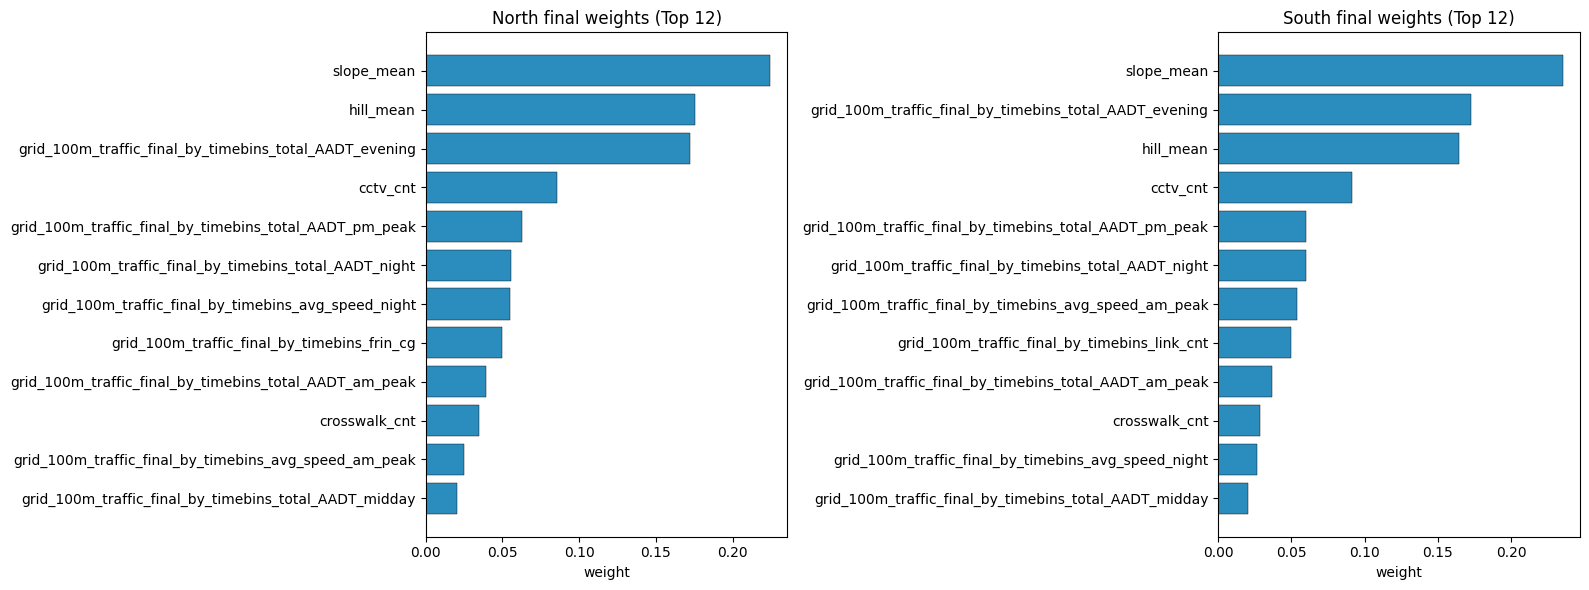

In [7]:
# 6) Visualization (final)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
for ax, data, title in [
    (axes[0], final_n.head(12).iloc[::-1], "North final weights (Top 12)"),
    (axes[1], final_s.head(12).iloc[::-1], "South final weights (Top 12)")
]:
    ax.barh(data["feature"], data["w_region"], color="#2b8cbe", edgecolor="black", linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel("weight")
plt.tight_layout()
plt.show()


# --------------------------------